In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
sns.set()

In [2]:
df=pd.read_csv('./data/student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df['parental_education_level'].fillna(df['parental_education_level'].mode())


0           Master
1      High School
2      High School
3           Master
4           Master
          ...     
995    High School
996    High School
997       Bachelor
998       Bachelor
999       Bachelor
Name: parental_education_level, Length: 1000, dtype: object

In [4]:
male=df.query('gender=="Male"')
sum_so_st_ex=male.groupby('age')[['social_media_hours','study_hours_per_day','exam_score']].sum().reset_index()
sum_so_st_ex.sort_values('exam_score',ascending=False)

,age,social_media_hours,study_hours_per_day,exam_score
7,24,161.1,261.1,5141.4
0,17,166.5,248.0,4829.9
3,20,175.0,225.2,4471.2
6,23,147.2,223.2,4444.4
1,18,143.0,180.4,3706.4
4,21,141.6,184.1,3639.9
5,22,128.6,182.3,3530.2
2,19,129.2,170.3,3325.3


In [5]:
corrlation=male.corr(numeric_only=True)
corrlation['exam_score']

age                      0.043669
study_hours_per_day      0.827474
social_media_hours      -0.137561
netflix_hours           -0.183020
attendance_percentage    0.091989
sleep_hours              0.152609
exercise_frequency       0.182899
mental_health_rating     0.332212
exam_score               1.000000
Name: exam_score, dtype: float64

In [6]:
corr_exam_score={}
for x,i in corrlation['exam_score'].items():
    if i >= 0.3 and x!='exam_score':
        corr_exam_score[x]=i

In [7]:
corr_exam_score

{'study_hours_per_day': 0.827473549964311,
 'mental_health_rating': 0.33221163523683334}

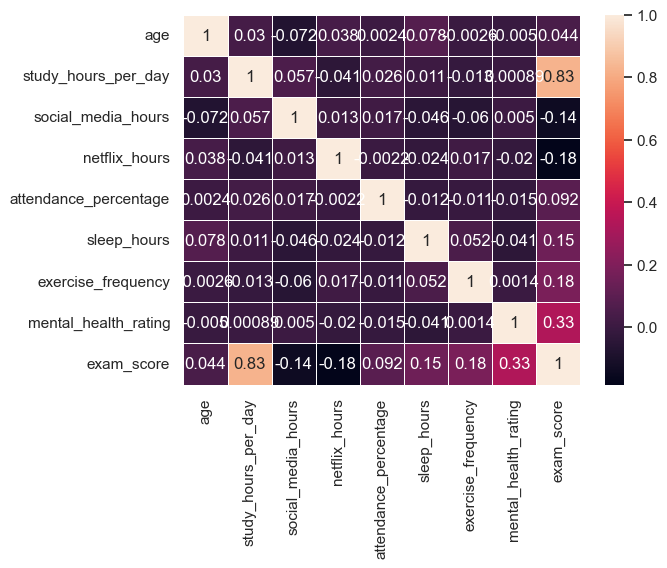

In [8]:
sns.heatmap(corrlation,linewidths=0.4,annot=True)
plt.show()

In [9]:
corrlation['sleep_hours'].sort_values(ascending=False)

sleep_hours              1.000000
exam_score               0.152609
age                      0.078498
exercise_frequency       0.051950
study_hours_per_day      0.010750
attendance_percentage   -0.012351
netflix_hours           -0.024371
mental_health_rating    -0.040695
social_media_hours      -0.045726
Name: sleep_hours, dtype: float64

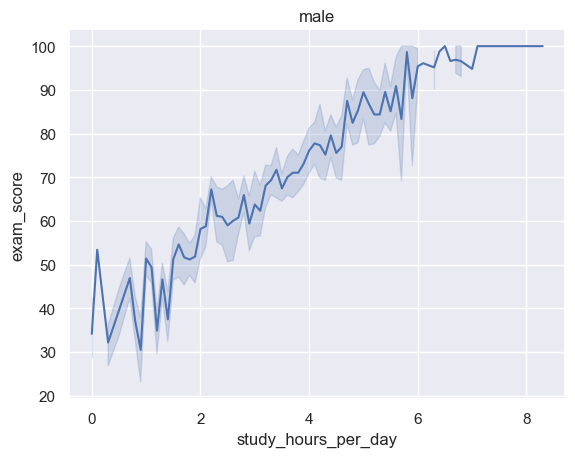

In [10]:

# plot 1
sns.lineplot(data=male,y='exam_score',x='study_hours_per_day')
plt.title('male')
plt.show()

In [11]:
corr_data_frame=df.corr(numeric_only=True)

corr_dic={}
for x , i in corr_data_frame['exam_score'].items():
    if i >= 0.5 and x != 'exam_score':
        corr_dic[x]=i

corr_dic

{'study_hours_per_day': 0.8254185093960438}

In [12]:
corr_data_frame['exam_score']

age                     -0.008907
study_hours_per_day      0.825419
social_media_hours      -0.166733
netflix_hours           -0.171779
attendance_percentage    0.089836
sleep_hours              0.121683
exercise_frequency       0.160107
mental_health_rating     0.321523
exam_score               1.000000
Name: exam_score, dtype: float64

In [13]:
df.groupby('gender')[['social_media_hours','exam_score','study_hours_per_day']].sum()

,social_media_hours,exam_score,study_hours_per_day
gender,,,
Female,1204.4,33545.6,1723.8
Male,1192.2,33088.7,1674.6
Other,108.9,2967.2,151.7


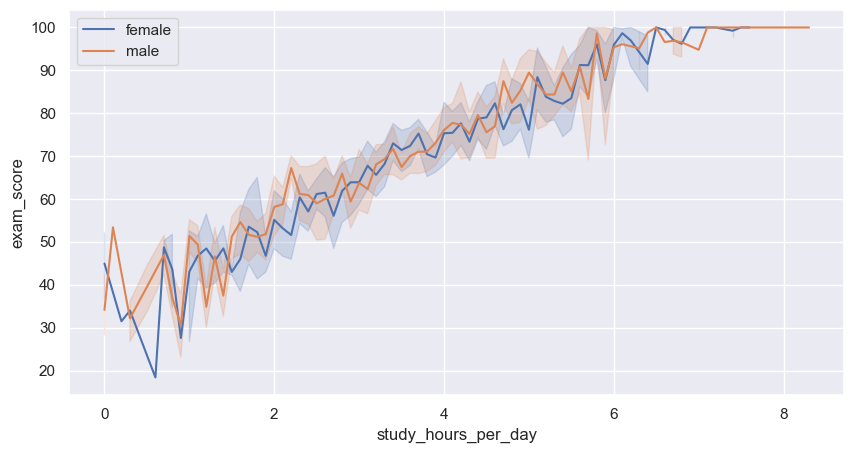

In [14]:
female=df.query('gender=="Female"')
plt.figure(figsize=(10,5))
sns.lineplot(data=female,x='study_hours_per_day',y='exam_score',label='female')
sns.lineplot(data=male,y='exam_score',x='study_hours_per_day',label='male')
# plt.legend

plt.show()

In [15]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


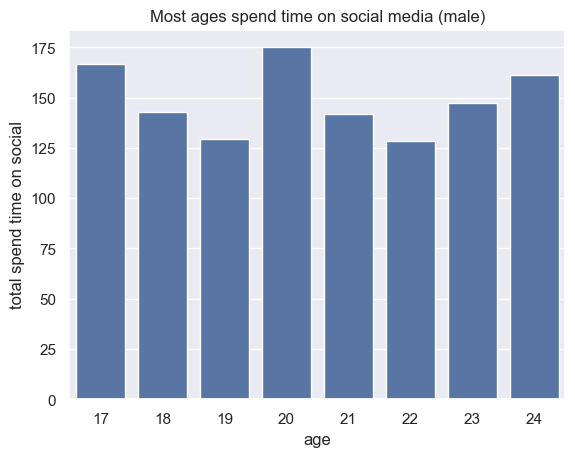

In [16]:
# bar 2
male_age_g=male.groupby('age')['social_media_hours'].sum().reset_index()
sns.barplot(data=male_age_g,x='age',y='social_media_hours')
plt.title('Most ages spend time on social media (male)')
plt.ylabel('total spend time on social')
plt.show()


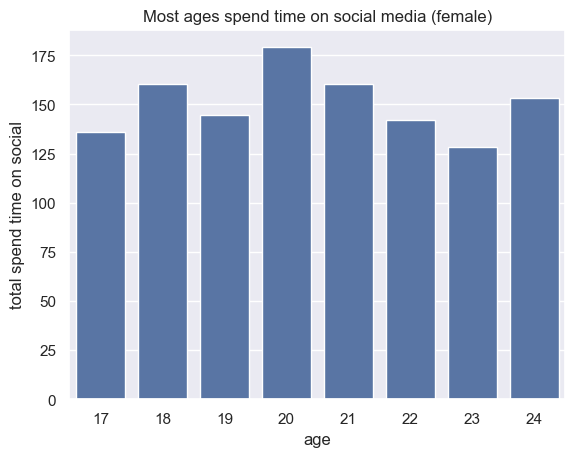

In [17]:
# bar 2
female_age_g=female.groupby('age')['social_media_hours'].sum().reset_index()
sns.barplot(data=female_age_g,x='age',y='social_media_hours')
plt.title('Most ages spend time on social media (female)')
plt.ylabel('total spend time on social')
plt.show()

In [18]:
pd.cut(x=df['age'],bins=5)

0        (22.6, 24.0]
1        (19.8, 21.2]
2        (19.8, 21.2]
3        (22.6, 24.0]
4        (18.4, 19.8]
            ...      
995      (19.8, 21.2]
996    (16.993, 18.4]
997      (19.8, 21.2]
998      (22.6, 24.0]
999      (18.4, 19.8]
Name: age, Length: 1000, dtype: category
Categories (5, interval[float64, right]): [(16.993, 18.4] < (18.4, 19.8] < (19.8, 21.2] < (21.2, 22.6] < (22.6, 24.0]]

In [50]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


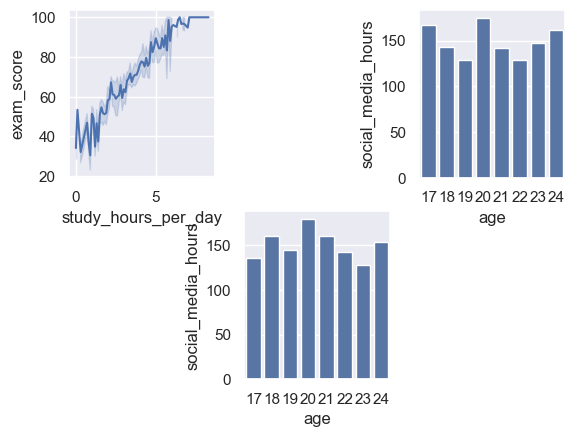

In [68]:
plt.subplot(2,3,1)
sns.lineplot(data=male,y='exam_score',x='study_hours_per_day')
plt.subplot(2,3,3)
sns.barplot(data=male_age_g,x='age',y='social_media_hours')
plt.subplot(2,3,5)
sns.barplot(data=female_age_g,x='age',y='social_media_hours')
plt.show()

student_id
S1000    1
S1013    1
S1030    1
S1029    1
S1002    1
        ..
S1994    1
S1995    1
S1996    1
S1997    1
S1999    1
Name: count, Length: 1000, dtype: int64